In [1]:
from torchvision import datasets, transforms

transform = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.ToTensor()
])

dataset = datasets.ImageFolder(
    "EuroSAT",
    transform=transform
)

FileNotFoundError: [WinError 3] The system cannot find the path specified: 'EuroSAT'

In [2]:
import os

print(os.getcwd())

C:\Users\RAGHAV


In [3]:
import os

print(os.listdir())

['.anaconda', '.arduinoIDE', '.conda', '.condarc', '.continuum', '.cursor', '.ipynb_checkpoints', '.ipython', '.jupyter', '.matplotlib', '.spyder-py3', '.vscode', '3D Objects', 'anaconda3', 'AppData', 'Application Data', 'BullseyeCoverageError.txt', 'ComputingAssignment_CASESTUDY1.py', 'ComputingAssignment_CASESTUDY2.py', 'ComputingAssignment_CASESTUDY3.py', 'ComputingAssignment_CASESTUDY4.py', 'ComputingAssignment_CASESTUDY5.py', 'ComputingAssignment_Q1.py', 'ComputingAssignment_Q2.py', 'ComputingAssignment_Q3.py', 'ComputingAssignment_Q4.py', 'ComputingAssignment_Q5.py', 'Contacts', 'Cookies', 'Desktop', 'Documents', 'Downloads', 'eurosat_cnn.ipynb', 'Favorites', 'IIT-JEE', 'IntelGraphicsProfiles', 'Jedi', 'Links', 'Local Settings', 'LumoraQ.ipynb', 'Music', 'My Documents', 'NetHood', 'NTUSER.DAT', 'ntuser.dat.LOG1', 'ntuser.dat.LOG2', 'NTUSER.DAT{6386d136-8e49-11ef-a652-928238c2ebc9}.TM.blf', 'NTUSER.DAT{6386d136-8e49-11ef-a652-928238c2ebc9}.TMContainer00000000000000000001.regtrans-

In [4]:
dataset = datasets.ImageFolder(
    r"C:\Users\YourName\Downloads\EuroSAT_RGB",
    transform=transform
)

FileNotFoundError: [WinError 3] The system cannot find the path specified: 'C:\\Users\\YourName\\Downloads\\EuroSAT_RGB'

In [5]:
dataset = datasets.ImageFolder(
    r"C:\Users\YOURNAME\Downloads\EuroSAT\2750",
    transform=transform
)

FileNotFoundError: [WinError 3] The system cannot find the path specified: 'C:\\Users\\YOURNAME\\Downloads\\EuroSAT\\2750'

In [6]:
dataset = datasets.ImageFolder(
    r"C:\Users\RAGHAV\Downloads\EuroSAT\2750",
    transform=transform
)

In [7]:
dataset = datasets.ImageFolder(
    r"C:\Users\RAGHAV\Downloads\EuroSAT\2750",
    transform=transform
)

print("Classes:", dataset.classes)
print("Number of images:", len(dataset))

Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
Number of images: 27000


In [8]:
from torch.utils.data import random_split, DataLoader

train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_dataset, test_dataset = random_split(
    dataset,
    [train_size, test_size]
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

print("Train:", len(train_dataset))
print("Test:", len(test_dataset))

Train: 21600
Test: 5400


In [9]:
import torch
import torch.nn as nn

class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2,2)

        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)

        self.fc1 = nn.Linear(32*16*16, 128)
        self.fc2 = nn.Linear(128, 10)

        self.relu = nn.ReLU()

    def forward(self, x):

        x = self.pool(self.relu(self.conv1(x)))

        x = self.pool(self.relu(self.conv2(x)))

        x = x.view(x.size(0), -1)

        x = self.relu(self.fc1(x))

        x = self.fc2(x)

        return x

model = SimpleCNN()

print(model)

SimpleCNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=8192, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
  (relu): ReLU()
)


In [10]:
import torch

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using:", device)

model = model.to(device)

Using: cpu


In [11]:
import torch.optim as optim
import torch.nn as nn

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

In [12]:
import torch.optim as optim
import torch.nn as nn

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

In [13]:
for epoch in range(1):

    running_loss = 0.0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    print(
        f"Epoch {epoch+1}, Loss: {running_loss/len(train_loader):.4f}"
    )

Epoch 1, Loss: 1.2602


In [14]:
correct = 0
total = 0

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total

print(f"Accuracy: {accuracy:.2f}%")

Accuracy: 67.61%


In [15]:
for epoch in range(5):

    model.train()

    running_loss = 0.0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    print(
        f"Epoch {epoch+1}/5, Loss: {running_loss/len(train_loader):.4f}"
    )

Epoch 1/5, Loss: 0.7596
Epoch 2/5, Loss: 0.6482
Epoch 3/5, Loss: 0.5764
Epoch 4/5, Loss: 0.5174
Epoch 5/5, Loss: 0.4694


In [16]:
correct = 0
total = 0

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total

print(f"Accuracy: {accuracy:.2f}%")

Accuracy: 79.87%


In [1]:
for epoch in range(15):

    model.train()

    running_loss = 0.0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    print(
        f"Epoch {epoch+1}/5, Loss: {running_loss/len(train_loader):.4f}"
    )

NameError: name 'model' is not defined

In [2]:
import torch
import torch.nn as nn

class StrongCNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.Conv2d(32, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(64 * 16 * 16, 256),

            nn.ReLU(),

            nn.Dropout(0.4),

            nn.Linear(256, 10)
        )

    def forward(self, x):

        x = self.features(x)
        x = self.classifier(x)

        return x

model = StrongCNN()
print(model)

StrongCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (9): ReLU()
    (10): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (12): ReLU()
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequenti

In [3]:
from torchvision import transforms

transform_train = transforms.Compose([

    transforms.Resize((64,64)),

    transforms.RandomHorizontalFlip(),

    transforms.RandomRotation(20),

    transforms.ColorJitter(),

    transforms.ToTensor()
])

In [4]:
from torchvision import datasets

dataset = datasets.ImageFolder(
    r"C:\Users\RAGHAV\Downloads\EuroSAT\2750",
    transform=transform_train
)

In [5]:
from torch.utils.data import random_split, DataLoader

train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_dataset, test_dataset = random_split(
    dataset,
    [train_size, test_size]
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

In [6]:
import torch.optim as optim

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = model.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.0005
)

In [7]:
for epoch in range(15):

    model.train()

    running_loss = 0.0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    print(
        f"Epoch {epoch+1}/15, Loss: {running_loss/len(train_loader):.4f}"
    )

Epoch 1/15, Loss: 1.1743
Epoch 2/15, Loss: 0.8330
Epoch 3/15, Loss: 0.7314
Epoch 4/15, Loss: 0.6761
Epoch 5/15, Loss: 0.6251
Epoch 6/15, Loss: 0.5839
Epoch 7/15, Loss: 0.5417
Epoch 8/15, Loss: 0.5202
Epoch 9/15, Loss: 0.4663
Epoch 10/15, Loss: 0.4414
Epoch 11/15, Loss: 0.4097
Epoch 12/15, Loss: 0.4017
Epoch 13/15, Loss: 0.3679
Epoch 14/15, Loss: 0.3444
Epoch 15/15, Loss: 0.3225


In [8]:
correct = 0
total = 0

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total

print(f"Accuracy: {accuracy:.2f}%")

Accuracy: 89.76%


In [9]:
all_preds = []
all_labels = []

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

In [10]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    all_labels,
    all_preds
)

print(cm)

[[578   3   4   5   0   6  18   0  17  10]
 [  4 560   1   0   0  12   1   0   2  11]
 [  8  19 430   7  11  29  62  14  18   0]
 [  9   1   4 392  21   4  10   3  39   0]
 [  0   0   0   1 489   0   0  22   1   0]
 [  9   0   2   1   0 359   3   0  13   3]
 [ 15   0  16   9   8   6 401   0  16   0]
 [  0   0   0   0   3   0   0 598   0   0]
 [ 11   4   0  14   1   4   1   0 473   4]
 [  1   3   0   0   0   0   0   0   1 595]]


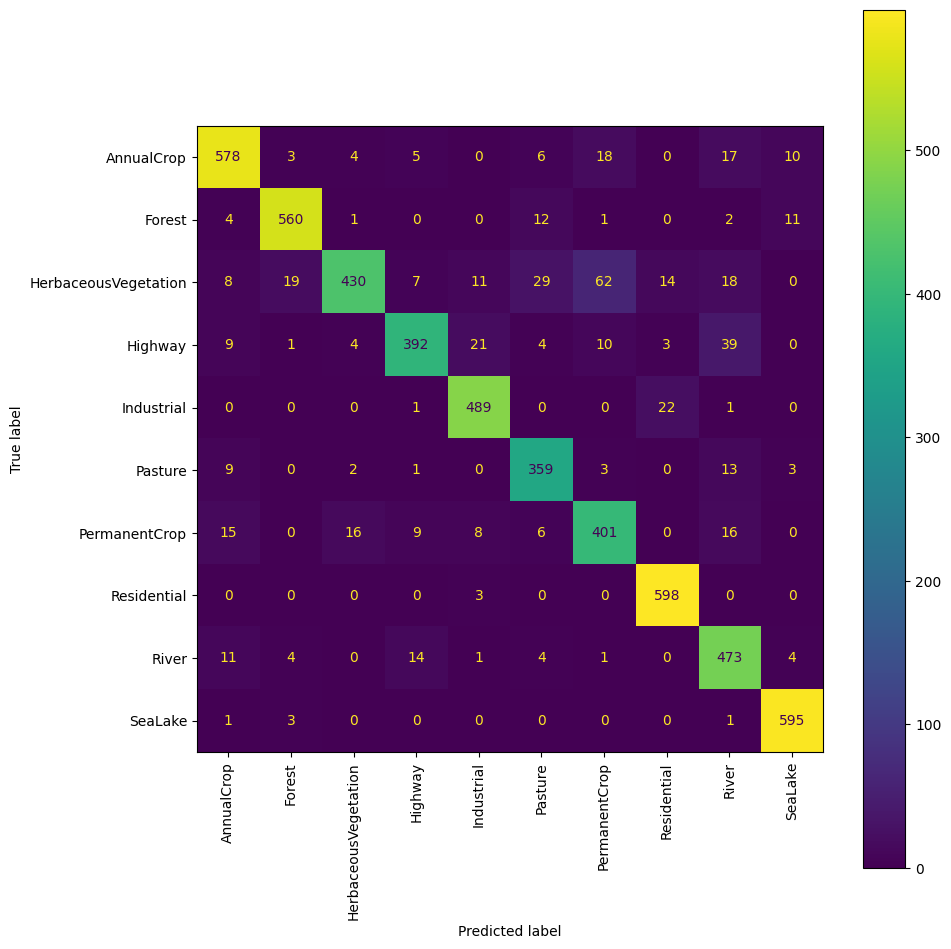

In [11]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(10,10))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=dataset.classes
)

disp.plot(
    ax=ax,
    xticks_rotation=90
)

plt.tight_layout()
plt.show()

In [12]:
from sklearn.metrics import classification_report

print(
    classification_report(
        all_labels,
        all_preds,
        target_names=dataset.classes
    )
)

                      precision    recall  f1-score   support

          AnnualCrop       0.91      0.90      0.91       641
              Forest       0.95      0.95      0.95       591
HerbaceousVegetation       0.94      0.72      0.82       598
             Highway       0.91      0.81      0.86       483
          Industrial       0.92      0.95      0.93       513
             Pasture       0.85      0.92      0.89       390
       PermanentCrop       0.81      0.85      0.83       471
         Residential       0.94      1.00      0.97       601
               River       0.82      0.92      0.87       512
             SeaLake       0.96      0.99      0.97       600

            accuracy                           0.90      5400
           macro avg       0.90      0.90      0.90      5400
        weighted avg       0.91      0.90      0.90      5400



In [13]:
torch.save(
    model.state_dict(),
    "strongcnn.pth"
)

In [14]:
import os
print(os.path.exists("strongcnn.pth"))

True


In [15]:
from torchvision import transforms

transform_train = transforms.Compose([

    transforms.Resize((64,64)),

    transforms.RandomHorizontalFlip(),

    transforms.RandomRotation(20),

    transforms.ColorJitter(),

    transforms.ToTensor()
])

In [16]:
print(len(dataset))
print(dataset.classes)

27000
['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


In [17]:
!pip install pennylane


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [20]:
!python -m pip install --upgrade pip

   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/1.8 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/1.8 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/1.8 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/1.8 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/1.8 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/1.8 MB ? eta -:--:--
   ----- -------------------------

In [22]:
import pennylane as qml

print(qml.__version__)

0.45.0


In [57]:
import pennylane as qml
from pennylane import numpy as np

In [58]:
dev = qml.device("default.qubit", wires=2)

In [59]:
@qml.qnode(dev)
def circuit(inputs, weights):

    # data encoding
    qml.RX(inputs[0], wires=0)
    qml.RY(inputs[1], wires=1)

    # trainable layer
    qml.Rot(weights[0], weights[1], weights[2], wires=0)
    qml.Rot(weights[3], weights[4], weights[5], wires=1)

    return qml.expval(qml.PauliZ(0))

In [60]:
print(qml.draw(circuit)([0.5, 0.2], np.zeros(6)))

0: ──RX(0.50)──Rot(0.00,0.00,0.00)─┤  <Z>
1: ──RY(0.20)──Rot(0.00,0.00,0.00)─┤     


In [61]:
inputs = np.array([0.5, 0.2])

In [62]:
weights = np.random.random(6)

In [63]:
    def loss(weights):
    output = circuit(inputs, weights)
    return (output - 1) ** 2

IndentationError: expected an indented block after function definition on line 1 (3879466877.py, line 2)

In [64]:
def loss(weights):
    output = circuit(inputs, weights)
    return (output - 1) ** 2


In [65]:
opt = qml.GradientDescentOptimizer(stepsize=0.1)

In [66]:
for step in range(100):

    weights = opt.step(loss, weights)

    if (step + 1) % 20 == 0:
        print(f"Step {step+1}: Loss = {loss(weights):.6f}")

Step 20: Loss = 0.030337
Step 40: Loss = 0.018537
Step 60: Loss = 0.016034
Step 80: Loss = 0.015287
Step 100: Loss = 0.015035


In [67]:
print("Final weights:", weights)
print("Final loss:", loss(weights))

Final weights: [0.06050172 0.00628578 0.94534126 0.957472   0.4648661  0.11028254]
Final loss: 0.01503492584930142


In [68]:
for x, y in zip(X, Y):

    prediction = vqc(x, weights)

    print(
        f"Input={x}, Prediction={prediction:.4f}, True={y}"
    )

Input=[0 0], Prediction=0.9982, True=-1
Input=[0 1], Prediction=0.9982, True=1
Input=[1 0], Prediction=0.5393, True=1
Input=[1 1], Prediction=0.5393, True=-1


In [69]:
print(model)

StrongCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (9): ReLU()
    (10): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (12): ReLU()
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequenti

In [70]:
type(model)

__main__.StrongCNN

In [71]:
print(model.features)

Sequential(
  (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (2): ReLU()
  (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (5): ReLU()
  (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (7): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (8): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (9): ReLU()
  (10): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (11): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (12): ReLU()
  (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
)


In [72]:
images, labels = next(iter(train_loader))

images = images.to(device)

with torch.no_grad():
    features = model.features(images)

print(features.shape)

torch.Size([32, 64, 16, 16])


In [73]:
flattened = features.view(features.size(0), -1)

print(flattened.shape)

torch.Size([32, 16384])


In [75]:
from sklearn.decomposition import PCA

In [76]:
features_np = flattened.cpu().numpy()

pca = PCA(n_components=4)

reduced_features = pca.fit_transform(features_np)

print(reduced_features.shape)

(32, 4)


In [77]:
print(reduced_features.shape)

(32, 4)


In [78]:
print(reduced_features[:5])

[[-13.506729    -2.6168582   -0.6711155   -2.6246898 ]
 [-21.032213    15.0224085   -0.65552044   4.3721194 ]
 [ 24.1018      -7.3245726   24.318003    -1.9966298 ]
 [-19.53078      8.278624    -3.1586475   -1.0724741 ]
 [  0.88442767 -14.971923    -3.657388     0.3963523 ]]


In [79]:
print(pca.explained_variance_ratio_)
print(sum(pca.explained_variance_ratio_))

[0.22401401 0.12904891 0.07825851 0.06912065]
0.5004421


In [80]:
import pennylane as qml
from pennylane import numpy as np

dev = qml.device("default.qubit", wires=4)

In [81]:
@qml.qnode(dev)
def feature_circuit(x):

    qml.RX(x[0], wires=0)
    qml.RX(x[1], wires=1)
    qml.RX(x[2], wires=2)
    qml.RX(x[3], wires=3)

    return [
        qml.expval(qml.PauliZ(0)),
        qml.expval(qml.PauliZ(1)),
        qml.expval(qml.PauliZ(2)),
        qml.expval(qml.PauliZ(3))
    ]

In [82]:
sample = reduced_features[0]

print(sample)
print(feature_circuit(sample))

[-13.506729   -2.6168582  -0.6711155  -2.6246898]
[np.float64(0.5894984681736899), np.float64(-0.8654570284407371), np.float64(0.7831284575307437), np.float64(-0.8693539341711002)]


In [83]:
print(sample)
print(feature_circuit(sample))

[-13.506729   -2.6168582  -0.6711155  -2.6246898]
[np.float64(0.5894984681736899), np.float64(-0.8654570284407371), np.float64(0.7831284575307437), np.float64(-0.8693539341711002)]


In [101]:
import os
print(os.getcwd()

_IncompleteInputError: incomplete input (3868109556.py, line 2)

In [102]:
import os
print(os.getcwd())

C:\Users\RAGHAV\Desktop\LumoraQ
